2026-03-24 04:48:52.649 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.651 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.656 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Index(['index', 'customer_id', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value'],
      dtype='object')


2026-03-24 04:48:52.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.850 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.916 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:52.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 04:48:53.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

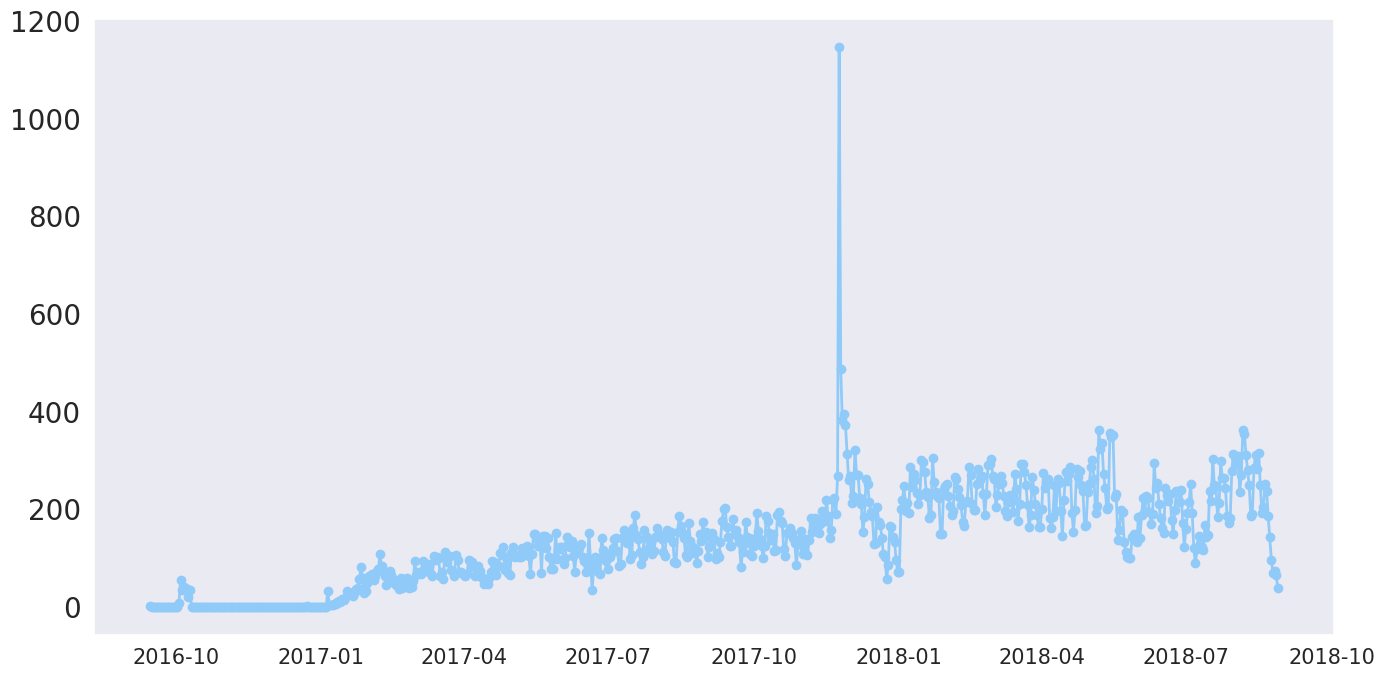

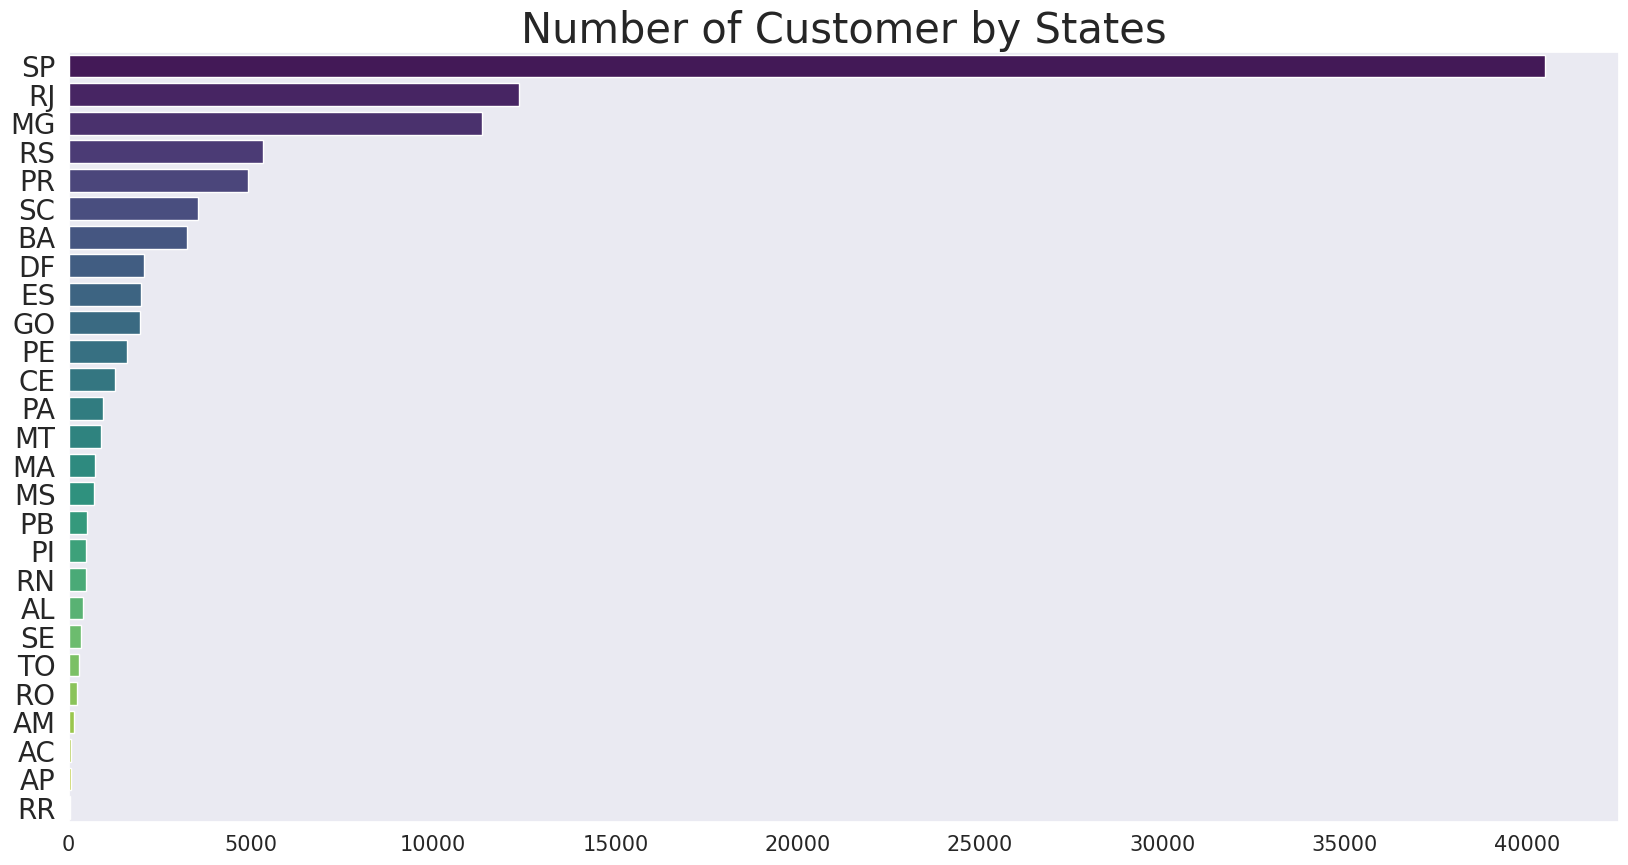

In [7]:
!pip install streamlit
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from babel.numbers import format_currency

sns.set(style='dark')

# Helper function untuk menyiapkan berbagai dataframe
def create_daily_orders_df(df):
    daily_orders_df = df.resample(rule='D', on='order_purchase_timestamp').agg({
        "order_id": "nunique",
        "payment_value": "sum"
    })
    daily_orders_df = daily_orders_df.reset_index()
    daily_orders_df.rename(columns={
        "order_id": "order_count",
        "payment_value": "revenue"
    }, inplace=True)
    return daily_orders_df

# def create_sum_order_items_df(df):
#     sum_order_items_df = df.groupby("product_category_name").product_id.count().sort_values(ascending=False).reset_index()
#     return sum_order_items_df

def create_bystate_df(df):
    bystate_df = df.groupby(by="customer_state").customer_id.nunique().reset_index()
    bystate_df.rename(columns={"customer_id": "customer_count"}, inplace=True)
    return bystate_df

# Load cleaned data
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date"]
all_df = pd.read_csv("main_data (1).csv")
all_df.sort_values(by="order_purchase_timestamp", inplace=True)
all_df.reset_index(inplace=True)

for column in datetime_columns:
    all_df[column] = pd.to_datetime(all_df[column])

print(all_df.columns)

# Filter Dashboard
min_date = all_df["order_purchase_timestamp"].min()
max_date = all_df["order_purchase_timestamp"].max()

with st.sidebar:
    # Menambahkan logo perusahaan (opsional)
    st.image("https://github.com/dicodingacademy/assets/raw/main/logo.png")

    # Mengambil start_date & end_date dari date_input
    start_date, end_date = st.date_input(
        label='Rentang Waktu',min_value=min_date,
        max_value=max_date,
        value=[min_date, max_date]
    )

main_df = all_df[(all_df["order_purchase_timestamp"] >= str(start_date)) &
                (all_df["order_purchase_timestamp"] <= str(end_date))]

# Menyiapkan berbagai dataframe
daily_orders_df = create_daily_orders_df(main_df)
# sum_order_items_df = create_sum_order_items_df(main_df) # Commented out due to missing column
bystate_df = create_bystate_df(main_df)

# DASHBOARD MAIN PAGE
st.header('E-Commerce Dashboard :sparkles:')

# Metric Total Order & Revenue
st.subheader('Daily Orders')
col1, col2 = st.columns(2)

with col1:
    total_orders = daily_orders_df.order_count.sum()
    st.metric("Total orders", value=total_orders)

with col2:
    total_revenue = format_currency(daily_orders_df.revenue.sum(), "BRL", locale='es_CO')
    st.metric("Total Revenue", value=total_revenue)

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(
    daily_orders_df["order_purchase_timestamp"],
    daily_orders_df["order_count"],
    marker='o',
    linewidth=2,
    color="#90CAF9"
)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=15)
st.pyplot(fig)

# Produk Terbaik & Terburuk (Commented out due to missing 'product_category_name')
# st.subheader("Best & Worst Performing Product")
# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(35, 15))

# colors = ["#90CAF9", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# sns.barplot(x="product_id", y="product_category_name", data=sum_order_items_df.head(5), palette=colors, ax=ax[0])
# ax[0].set_ylabel(None)
# ax[0].set_xlabel("Number of Sales", fontsize=30)
# ax[0].set_title("Best Performing Product", loc="center", fontsize=50)
# ax[0].tick_params(axis='y', labelsize=35)
# ax[0].tick_params(axis='x', labelsize=30)

# sns.barplot(x="product_id", y="product_category_name", data=sum_order_items_df.sort_values(by="product_id", ascending=True).head(5), palette=colors, ax=ax[1])
# ax[1].set_ylabel(None)
# ax[1].set_xlabel("Number of Sales", fontsize=30)
# ax[1].invert_xaxis()
# ax[1].yaxis.set_label_position("right")
# ax[1].yaxis.tick_right()
# ax[1].set_title("Worst Performing Product", loc="center", fontsize=50)
# ax[1].tick_params(axis='y', labelsize=35)
# ax[1].tick_params(axis='x', labelsize=30)

# st.pyplot(fig)

# Customer Demographics
st.subheader("Customer Demographics")
fig, ax = plt.subplots(figsize=(20, 10))
sns.barplot(
    x="customer_count",
    y="customer_state",
    data=bystate_df.sort_values(by="customer_count", ascending=False),
    palette="viridis",
    ax=ax
)
ax.set_title("Number of Customer by States", loc="center", fontsize=30)
ax.set_ylabel(None)
ax.set_xlabel(None)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=15)
st.pyplot(fig)

st.caption('Copyright (c) Mareska Radela Putra 2024')